$$\text{PROJECT 2}$$

In [19]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

##### **Config**

In [20]:
urls = ['bone.jpg', 'khunglong.png']

kernel = {
    'laplacian': np.array([[0, 1, 0], 
                           [1,-4, 1], 
                           [0, 1, 0]]),
    'sobel_x': np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype = np.float64),
    'sobel_y': np.array([[-1,-2,-1],
                         [ 0, 0, 0],
                         [ 1, 2, 1]], dtype = np.float64)                
}

##### **1. Combining Spatial Enhancement Methods**

**Function**

In [21]:
def read_image(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    return img.astype(np.float64)

def normalize_image(image):
    if np.max(image) == np.min(image):
        return np.zeros_like(image)
    return ((image - np.min(image)) * 255 / (np.max(image) - np.min(image))).astype(np.uint8)

def apply_laplacian(image):
    return normalize_image(ndimage.convolve(image, kernel['laplacian']))


def sharpen_image(original, laplacian):
    return normalize_image(original - laplacian)

def sobel_filter(image):
    gradient_x = ndimage.convolve(image.astype(float), kernel['sobel_x'])
    gradient_y = ndimage.convolve(image.astype(float), kernel['sobel_y'])
    magnitude = np.sqrt(np.square(gradient_x) + np.square(gradient_y))
    return normalize_image(magnitude)

def smoothed_image(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
    return normalize_image(ndimage.convolve(image, kernel))

def multiply_images(img1, img2):
    product = (img1.astype(np.float32) * img2.astype(np.float32)) / 255.0
    return normalize_image(product)

def add_images(img1, img2):
    result = img1 + img2
    return normalize_image(result)

def power_law_transform(image, gamma=0.5):
    normalized = image / 255.0
    result = np.power(normalized, gamma) * 255.0
    return normalize_image(result)


**Processing**

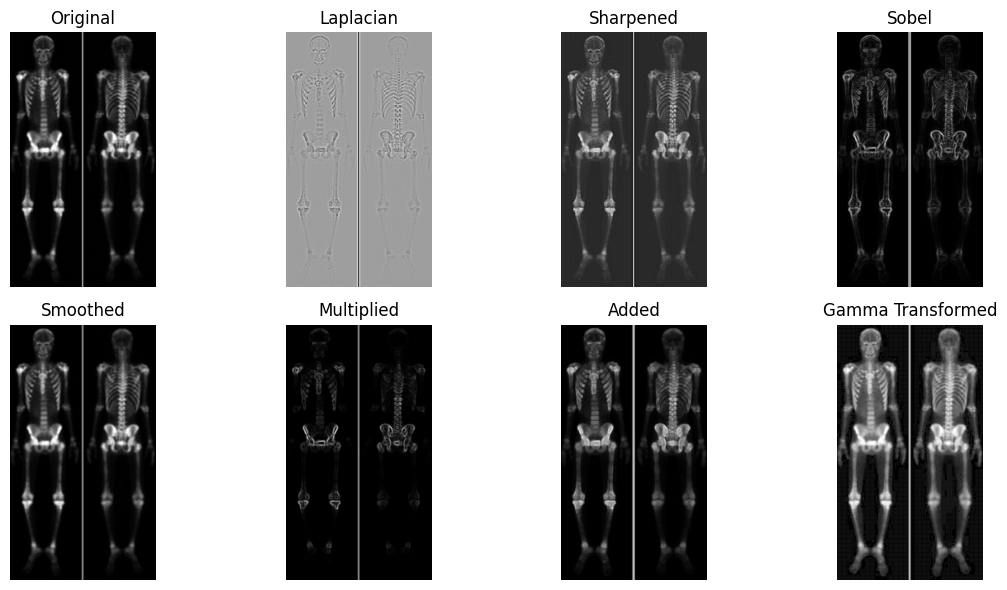

In [22]:
origin_image = read_image(urls[0])
laplacian_image = apply_laplacian(origin_image)
sharpened_image = sharpen_image(origin_image, laplacian_image)
sobel_image = sobel_filter(origin_image)
smoothed_image = smoothed_image(origin_image, 3)
multiplied_image = multiply_images(origin_image, sobel_image)
added_image = add_images(origin_image, sobel_image)
gamma_transformed = power_law_transform(origin_image, 0.5)

list_images = [origin_image, laplacian_image, sharpened_image, sobel_image, smoothed_image, multiplied_image, added_image, gamma_transformed]
list_titles = ['Original', 'Laplacian', 'Sharpened', 'Sobel', 'Smoothed', 'Multiplied', 'Added', 'Gamma Transformed']

plt.figure(figsize=(12, 6))
for i in range(len(list_images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(list_images[i], cmap='gray')
    plt.title(list_titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

##### **2. Find Contours Function**

**Function**

In [23]:
def threshold_image(image, threshold):
    rows, cols = image.shape                                # Lấy kích thước của ảnh (số hàng và số cột).
    binary_image = image.copy()                             # Tạo một bản sao của ảnh để tránh làm thay đổi ảnh gốc.
    
    for r in range(rows):
        for c in range(cols):
            if binary_image[r, c] <= threshold:
                binary_image[r, c] = 0
            else:
                binary_image[r, c] = 255
    
    return binary_image

def gray2bgr(image):
    result = np.stack((image,) * 3, axis=-1)                # Nhân ba ma trận ảnh để tạo ra ảnh màu 3 kênh (R,G,B) từ ảnh xám.
    return result  

def is_contour_pixel(image, x, y):                          # Hàm kiểm tra xem một pixel có phải là pixel viền không.
    if image[x, y] == 255:  
        if (x > 0 and image[x - 1, y] == 0) or \
           (x < image.shape[0] - 1 and image[x + 1, y] == 0) or \
           (y > 0 and image[x, y - 1] == 0) or \
           (y < image.shape[1] - 1 and image[x, y + 1] == 0):
            return True 
    return False

def find_contours_list(image):
    contour_points = []                                     # Khởi tạo danh sách để lưu các điểm trên đường viền.
    rows, cols = image.shape                                # Lấy số hàng và số cột của ảnh.
    binary_image = threshold_image(image, 127)              # Chuyển ảnh về ảnh nhị phân với ngưỡng 127.
    for i in range(rows):
        for j in range(cols):
            if is_contour_pixel(binary_image, i, j):        # Nếu pixel (i, j) là pixel viền thì thêm vào danh sách.
                contour_points.append((i, j))
    
    return contour_points 

def find_contours_external(image):
    rows, cols = image.shape                                # Lấy số hàng và số cột của ảnh (kích thước của ảnh xám).
    binary_image = threshold_image(image, 127)              # Chuyển ảnh về ảnh nhị phân với ngưỡng 127.
    target_points = set()                                   # Khởi tạo một tập hợp để lưu các điểm viền ngoài.
    for r in range(rows):
        cols_with_edges = [c for c in range(cols) if is_contour_pixel(binary_image, r, c)]
        if len(cols_with_edges) > 0:                        # Nếu có bất kỳ pixel viền nào trong hàng này thì thêm vào.
            target_points.add((r, min(cols_with_edges)))    # Viền ngoài cùng bên trái.
            target_points.add((r, max(cols_with_edges)))    # Viền ngoài cùng bên phải.

    for c in range(cols):
        rows_with_edges = [r for r in range(rows) if is_contour_pixel(binary_image, r, c)]
        if len(rows_with_edges) > 0:
                
            target_points.add((min(rows_with_edges), c))    # Viền ngoài cùng ở trên.
            target_points.add((max(rows_with_edges), c))    # Viền ngoài cùng ở dưới.

    return list(target_points)

def draw_contours(image, contours, color):
    image = gray2bgr(image)                                 # Chuyển đổi ảnh xám thành ảnh màu.
    for point in contours:
        for d in range(-3, 1):
            for e in range(-3, 1):
                image[point[0] + d, point[1] + e] = color   # Gán màu cho các pixel xung quanh điểm viền.
    
    return image 


**Processing**

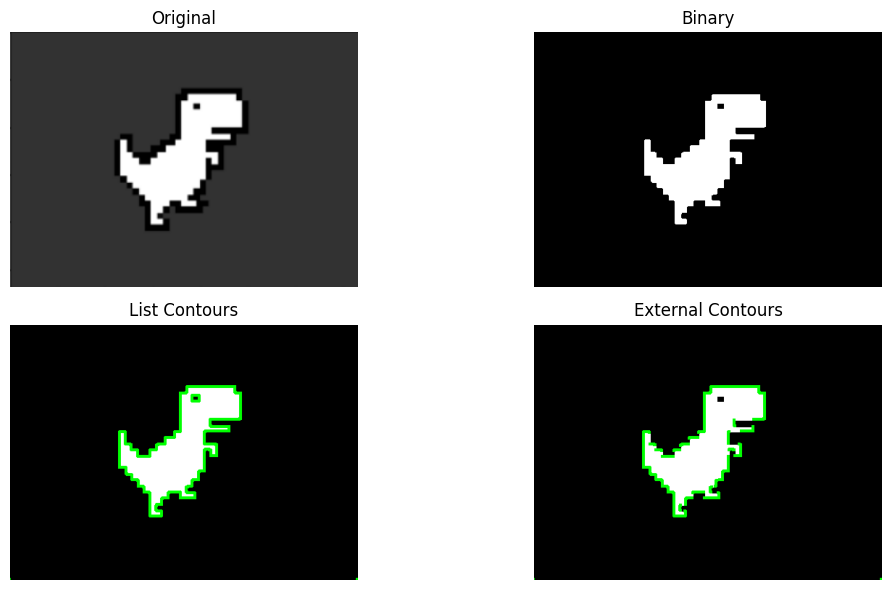

In [24]:
img2 = cv2.imread('khunglong.png')                          # Đọc ảnh cần xử lý

gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)               # Chuyển ảnh sang ảnh xám

binary = threshold_image(gray, 127)                         # Chuyển ảnh xám sang ảnh nhị phân

dinousaur_img1 = binary.copy()                              # Copy ảnh nhị phân
dinousaur_img2 = binary.copy()                              # Copy ảnh nhị phân

contours_list = find_contours_list(gray)                    # Áp dụng phương pháp tìm contours theo list
contours_external = find_contours_external(gray)            # Áp dụng phương pháp tìm contours theo external

h, w = binary.shape                                         # Lấy kích thước ảnh
color = [0, 255, 0]                                         # Màu trắng
output_image_list =  draw_contours(dinousaur_img1,contours_list, color) # Vẽ contours theo list
output_image_external = draw_contours(dinousaur_img2, contours_external, color ) # Vẽ contours theo external

# Hiển thị ảnh
list_images = [img2 ,binary, output_image_list, output_image_external]
list_titles = ['Original', 'Binary', 'List Contours', 'External Contours']

plt.figure(figsize=(12, 6))
for i in range(len(list_images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(list_images[i], cmap='gray')
    plt.title(list_titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

##### **3. Dice Recognition**

**Config**

In [25]:
link_imgs = ['dice1.jpg', 'dice2.jpg', 'dice3.jpg', 'dice4.jpg']

**Function**

In [26]:
def function1(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 0)
    edges = cv2.Canny(blur, 100, 200)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,param1=50, param2=30, minRadius=10, maxRadius=30)

    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        for (x, y, r) in circles:
            cv2.circle(image, (x, y), r, (0, 255, 0), 4)
        num_dots = circles.shape[0]
        cv2.putText(image, f"Score: {num_dots}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX,1.5, (0, 255, 0), 4)
    return image, gray, blur, edges

def function2(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 0)
    edges = cv2.Canny(blur, 100, 200)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    image_origin = image.copy()
    
    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        roi = blur[y:y + h, x:x + w]
        circles = cv2.HoughCircles(edges[y:y + h, x:x + w], cv2.HOUGH_GRADIENT,dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        circle_centers = []
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            num_dots = len(circles)
            for (cx, cy, r) in circles:
                cv2.circle(image_origin, (cx + x, cy + y), r, (0, 255, 0), 2)
                cv2.circle(image_origin, (cx + x, cy + y), 3, (255, 0, 0), -1)

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        roi = blur[y:y + h, x:x + w]
        circles = cv2.HoughCircles(edges[y:y + h, x:x + w], cv2.HOUGH_GRADIENT,dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            num_dots = len(circles)            
            for (cx, cy, r) in circles:
                cv2.circle(image, (cx + x, cy + y), r, (0, 255, 0), 2)
                cv2.circle(image, (cx + x, cy + y), 3, (255, 0, 0), -1)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(image, f"score: {num_dots}", (x + 5, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    return image, image_origin, gray, edges

def function3(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 0)
    edges = cv2.Canny(blur, 100, 200)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    origin_image = image.copy()

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (cx, cy, r) in circles:
                if x <= cx <= x + w and y <= cy <= y + h:
                    cv2.circle(origin_image, (cx, cy), r, (0, 255, 0), 2)
                    num_dots += 1
                    cv2.circle(origin_image, (cx, cy), 5, (255, 0, 0), -1)

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (cx, cy, r) in circles:
                if x <= cx <= x + w and y <= cy <= y + h:
                    cv2.circle(image, (cx, cy), r, (0, 255, 0), 2)
                    num_dots += 1
                    cv2.circle(image, (cx, cy), 5, (255, 0, 0), -1)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(image, f"Score: {num_dots}", (x + w // 5, y + h // 1), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3, cv2.LINE_AA)
    return image,origin_image, gray, edges

def function4(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 0)
    edges = cv2.Canny(blur, 100, 200)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    thresh = cv2.bitwise_not(thresh)
    kernel = np.ones((5, 5), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    origin_image = image.copy()

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (cx, cy, r) in circles:
                if x <= cx <= x + w and y <= cy <= y + h:
                    cv2.circle(origin_image, (cx, cy), r, (0, 255, 0), 2)
                    num_dots += 1
                    cv2.circle(origin_image, (cx, cy), 5, (255, 0, 0), -1)

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1.2, minDist=10,param1=50, param2=20, minRadius=5,maxRadius=20)
        num_dots = 0
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (cx, cy, r) in circles:
                if x <= cx <= x + w and y <= cy <= y + h:
                    cv2.circle(image, (cx, cy), r, (0, 255, 0), 2)
                    num_dots += 1
                    cv2.circle(image, (cx, cy), 5, (255, 0, 0), -1)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(image, f"Score: {num_dots}", (x + w // 5, y + h // 1), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3, cv2.LINE_AA)

    return image,thresh, origin_image, gray, edges

**Processing**

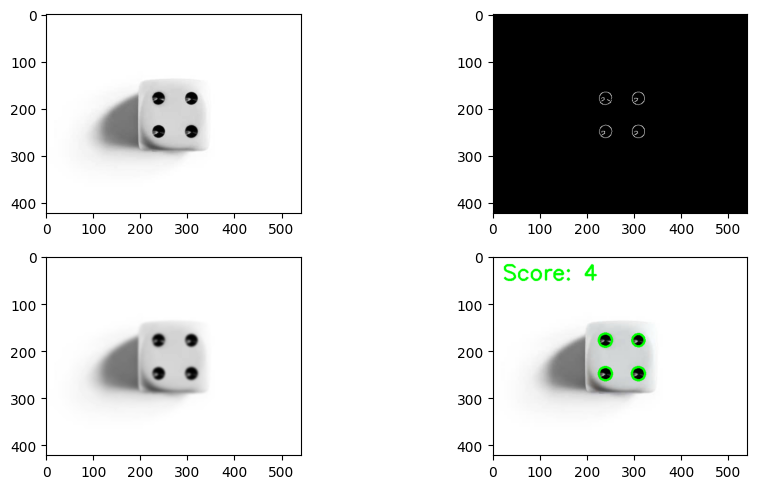

In [27]:
image_dice1 = cv2.imread(link_imgs[0])
img1, gray1, blur1, edges1 = function1(image_dice1)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.subplot(2, 2, 2)
plt.imshow(edges1, cmap='gray')
plt.subplot(2, 2, 3)
plt.imshow(blur1, cmap='gray')
plt.subplot(2, 2, 4)
plt.imshow(img1)
plt.tight_layout()
plt.show()


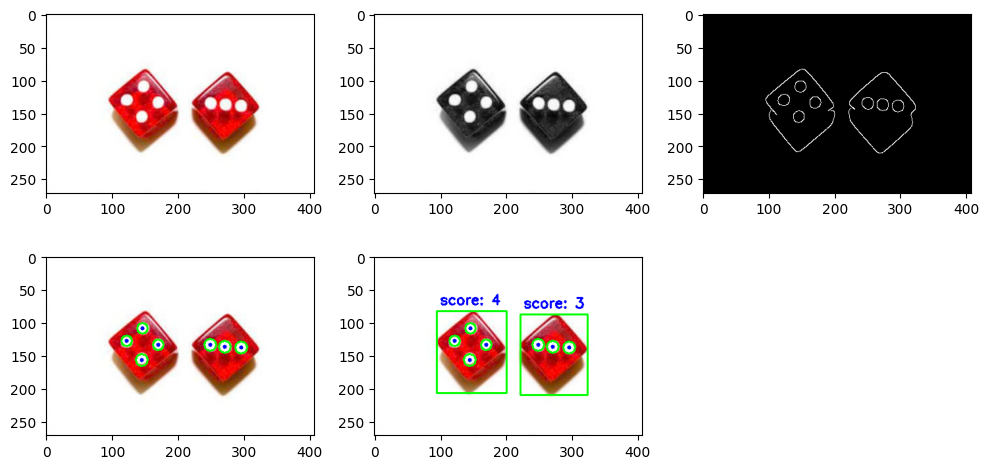

In [28]:
image_dice2 = cv2.imread(link_imgs[1])
temp_img2 = image_dice2.copy()
result2, drawdot_img2, gray2, edges2 = function2(temp_img2)

image_dice2 = cv2.cvtColor(image_dice2, cv2.COLOR_BGR2RGB)
result = cv2.cvtColor(result2, cv2.COLOR_BGR2RGB)
drawdot_img = cv2.cvtColor(drawdot_img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(2, 3, 1)
plt.imshow(image_dice2, cmap='gray')
plt.subplot(2, 3, 2)
plt.imshow(gray2, cmap='gray')
plt.subplot(2, 3, 3)
plt.imshow(edges2, cmap='gray')
plt.subplot(2, 3, 4)
plt.imshow(drawdot_img)
plt.subplot(2, 3, 5)
plt.imshow(result)
plt.tight_layout()
plt.show()

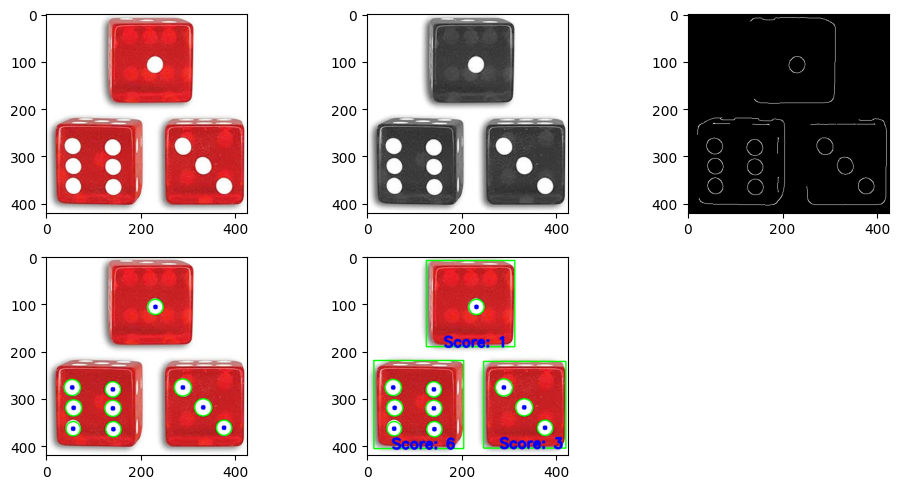

In [29]:
image_dice3 = cv2.imread(link_imgs[2])
temp_img3 = image_dice3.copy()
result3 ,drawdot_img3, gray3, edges3 = function3(temp_img3)

image_dice3 = cv2.cvtColor(image_dice3, cv2.COLOR_BGR2RGB)
result3 = cv2.cvtColor(result3, cv2.COLOR_BGR2RGB)
drawdot_img3 = cv2.cvtColor(drawdot_img3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.imshow(image_dice3, cmap='gray')
plt.subplot(2, 3, 2)
plt.imshow(gray3, cmap='gray')
plt.subplot(2, 3, 3)
plt.imshow(edges3, cmap='gray')
plt.subplot(2, 3, 4)
plt.imshow(drawdot_img3)
plt.subplot(2, 3, 5)
plt.imshow(result3)
plt.tight_layout()
plt.show()

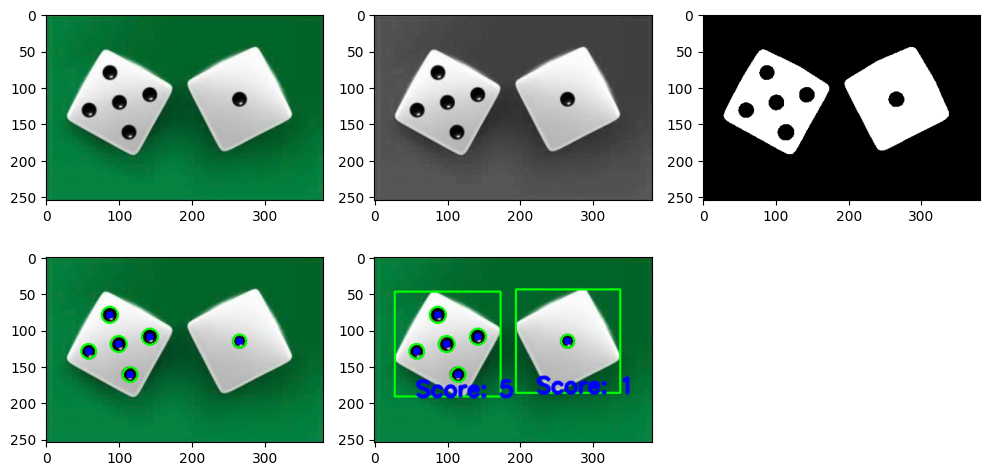

In [30]:
image_dice4 = cv2.imread(link_imgs[3])

temp_img4 = image_dice4.copy()

result4, threshold4, origin4, gray4, edges4 = function4(temp_img4)

result4 = cv2.cvtColor(result4, cv2.COLOR_BGR2RGB)
threshold4 = cv2.cvtColor(threshold4, cv2.COLOR_BGR2RGB)
origin4 = cv2.cvtColor(origin4, cv2.COLOR_BGR2RGB)
image_dice4 = cv2.cvtColor(image_dice4, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.imshow(image_dice4)
plt.subplot(2, 3, 2)
plt.imshow(gray4, cmap='gray')
plt.subplot(2, 3, 3)
plt.imshow(threshold4)
plt.subplot(2, 3, 4)
plt.imshow(origin4)
plt.subplot(2, 3, 5)
plt.imshow(result4)
plt.tight_layout()
plt.show()
